In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import plotly.graph_objects as go
import itertools
from scipy.signal import find_peaks
from matplotlib import pyplot as plt
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

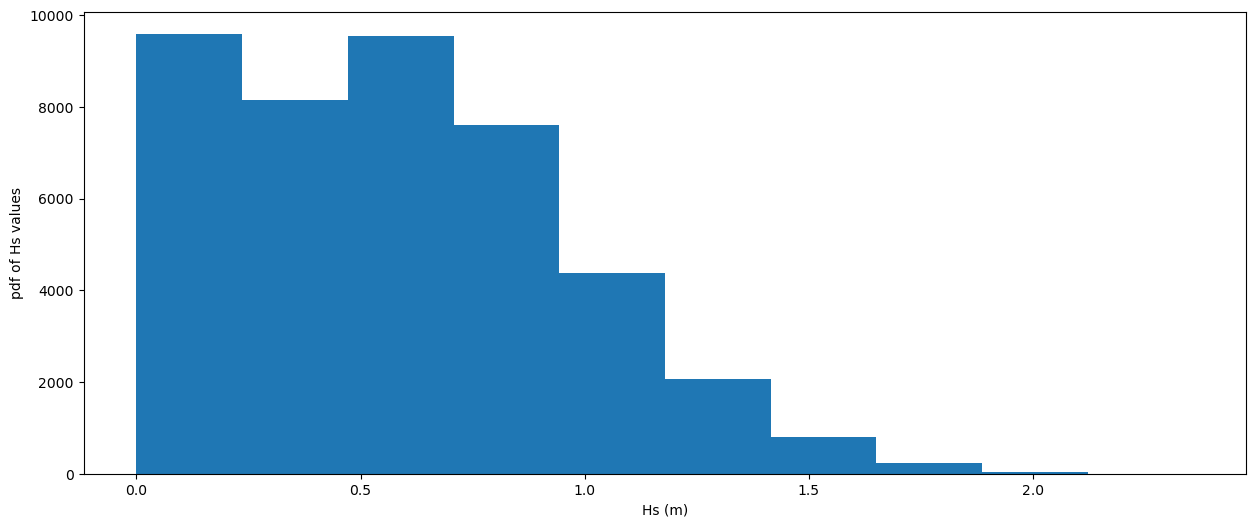

Number of Hs values:  42372

0        1996-01-01 00:00:00
1        1996-01-01 06:00:00
2        1996-01-01 12:00:00
3        1996-01-01 18:00:00
4        1996-01-02 00:00:00
                ...         
42367    2025-12-30 18:00:00
42368    2025-12-31 00:00:00
42369    2025-12-31 06:00:00
42370    2025-12-31 12:00:00
42371    2025-12-31 18:00:00
Name: time, Length: 42372, dtype: object


In [ ]:
wave_data = pd.read_csv('total_data.csv')
time_series = wave_data['Hs_wind']
period_series = wave_data['Peak_period']
time_values = wave_data['time']

# 
#  Extract Hs from database and plot histogram
#

fig, ax = plt.subplots(1, 1)
plt.xlabel('Hs (m)')
plt.ylabel('pdf of Hs values')
ax.hist(time_series, histtype='stepfilled')
plt.show()

#
imax = len(time_series)
print('Number of Hs values: ',imax)
print()
dft = wave_data.get("time")
print(dft)
pass

In [ ]:
#
# Peak Over Through code
def pot_method(data, threshold, dtime):
    idx_pot, _ = find_peaks(data, height = threshold, distance = dtime)
    pot_list = data.loc[idx_pot]
    return idx_pot, pot_list
#

figwave = go.Figure()

figwave.add_trace(go.Scatter(
    x=time_values,
    y=time_series,
    mode='lines',
    name='Hs time series'
))

figwave.update_layout(
    xaxis_title='Date',
    yaxis_title='Hs [m]',
    title='Significant wave height time series'
)

figwave.show()

In [ ]:
#
# threshold is the Hs threshold value
# dtime is the number of values used in time (here 4 * 3 hour samples = 12 hrs)
#
threshold = 0.9
dtime = 12
tare = threshold

indices,pot_maxima = pot_method(time_series, threshold, dtime)

kmax = len(pot_maxima)
print("Number of peaks based on Threshold: ",threshold," and time ",dtime," is ",kmax)
print('Last part of the calculated Peaks over Threshold values: ')
print(pot_maxima.tail())

Number of peaks based on Threshold:  0.9  and time  12  is  1408
Last part of the calculated Peaks over Threshold values: 
42273    1.386963
42285    1.069092
42306    1.089844
42330    1.440918
42350    1.002441
Name: Hs_wind, dtype: float64


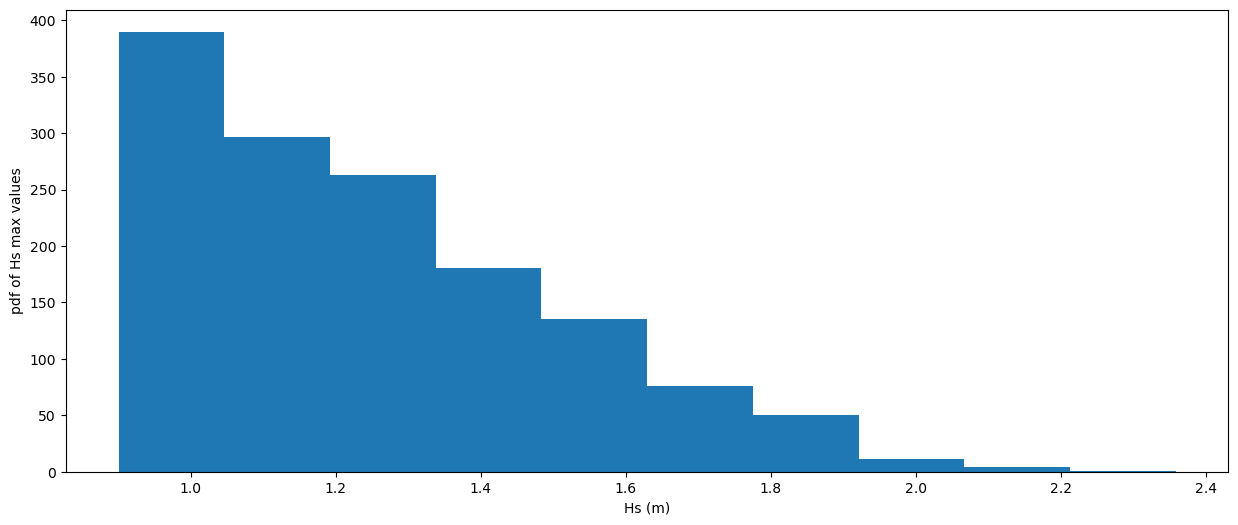

In [ ]:
#
#
# following is a subsegment to extract part of the data for visualization
# NB: j is starting value op peaks and range is number of points to be visualized
#
sub_ind = []
j = 100
for i in range(0,24):
    k = j + i
    val = indices[k]
    sub_ind.append(val)
#
sub_pot = pot_maxima.loc[sub_ind]

#
# Update numbers based on range!
#
inst = sub_ind[0]
inen = sub_ind[23]
sub_tim = time_series[inst:inen]
sub_pos = list(itertools.chain(range(inst, inen)))
#
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sub_pos,y=sub_tim,
    mode='lines',
    name='Original Plot'
))

#
#
fig.add_trace(go.Scatter(
    x=sub_ind,y=sub_pot,
    mode='markers',
    marker=dict(
        size=8,
        color='red',
        symbol='cross'
    ),
    name='Detected Peaks'
))

fig.show()

#
pot_time = []
for i in range(0,kmax):
    val = indices[i]
    pot_time.append(dft[val])
#
fig, ax = plt.subplots(1, 1)
plt.xlabel('Hs (m)')
plt.ylabel('pdf of Hs max values')
ax.hist(pot_maxima, histtype='stepfilled')
plt.show()
#
pass

In [ ]:
array = np.array([indices, 
         pot_time,
         pot_maxima,
         period_series.loc[indices]
         ])

array = array.T

df = pd.DataFrame(array, columns=['index', 'pot_time', 'pot_maxima', 'Peak_period'])

df.to_csv('EVA result POT wind waves.csv', index=False)


In [ ]:
import reliability.Fitters as rf

In [ ]:
dfmax = []
for it in pot_maxima.items():
    val = it[1] - tare # pot_maxima[i]
    dfmax.append(val)    
dfmax.sort()

Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1408/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha        0.373285      0.00839932   0.35718  0.390116
     Beta         1.24221       0.0269119   1.19057   1.29609 

Goodness of fit    Value
 Log-likelihood  117.117
           AICc -230.225
            BIC -219.734
             AD   4.8294 



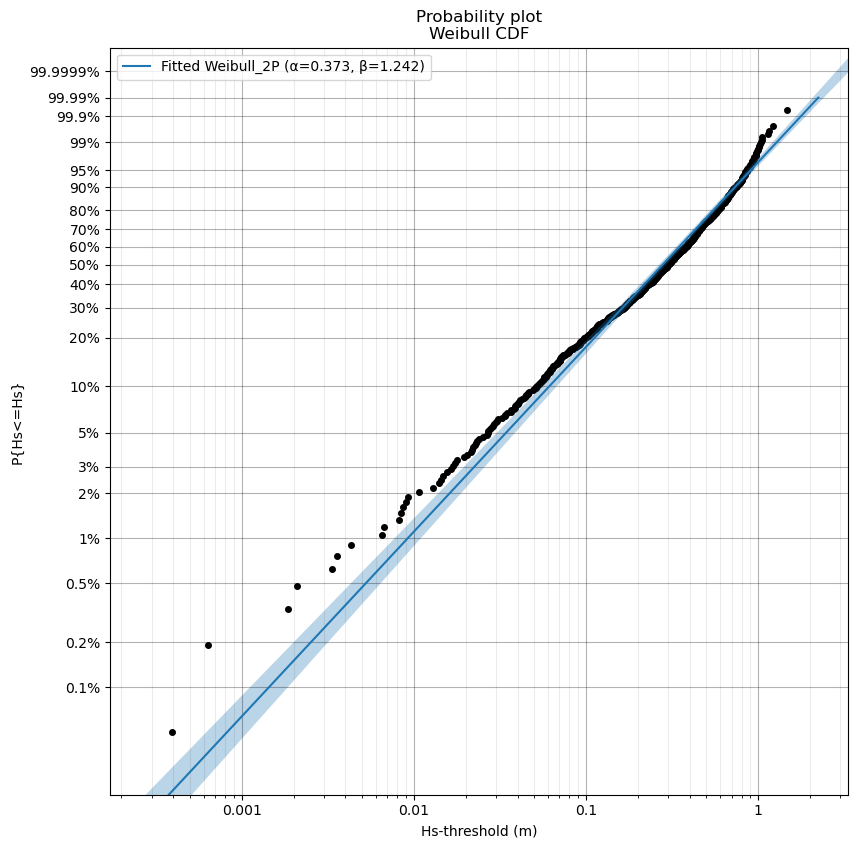

In [ ]:
waw2 = rf.Fit_Weibull_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

Results from Fit_Weibull_3P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1408/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha        0.373285      0.00839932   0.35718  0.390116
     Beta         1.24221       0.0269119   1.19057   1.29609
    Gamma               0               0         0         0 

Goodness of fit    Value
 Log-likelihood  117.117
           AICc -228.216
            BIC -212.484
             AD   4.8294 



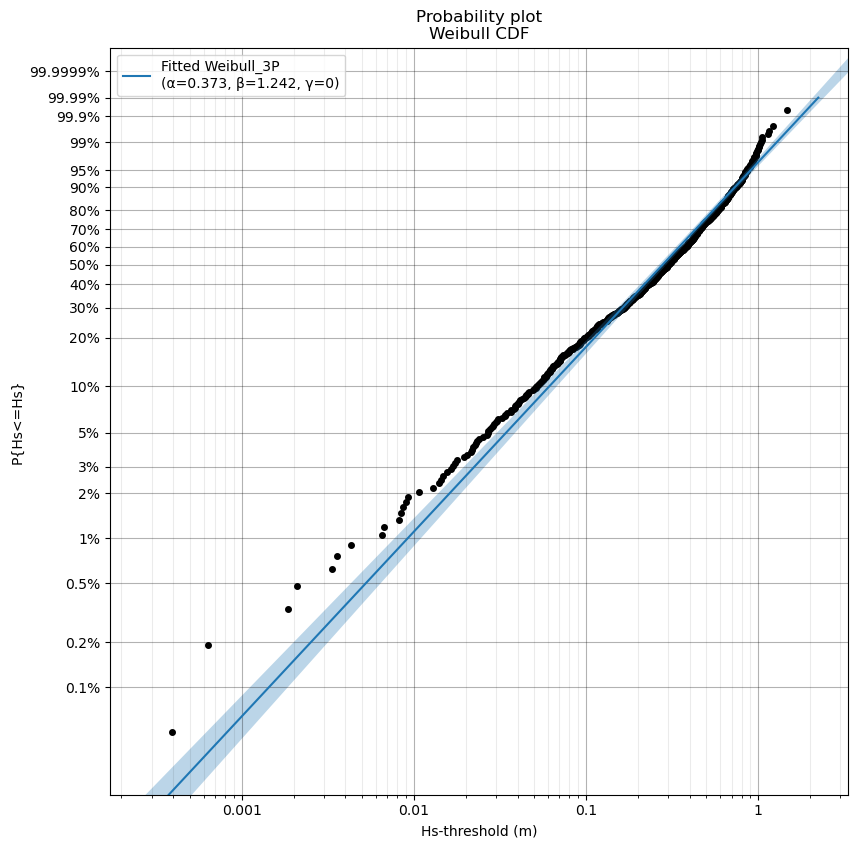

In [ ]:
#
#  Weibull 3P fit delivers alpha = scale factor, beta = shape factor & gamma = location factor

waw3 = rf.Fit_Weibull_3P(failures=dfmax)

plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()


Results from Fit_Gumbel_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1408/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
       Mu        0.489828      0.00850594  0.473156  0.506499
    Sigma        0.299969       0.0054556  0.289464  0.310854 

Goodness of fit   Value
 Log-likelihood -370.71
           AICc 745.429
            BIC  755.92
             AD 56.1634 



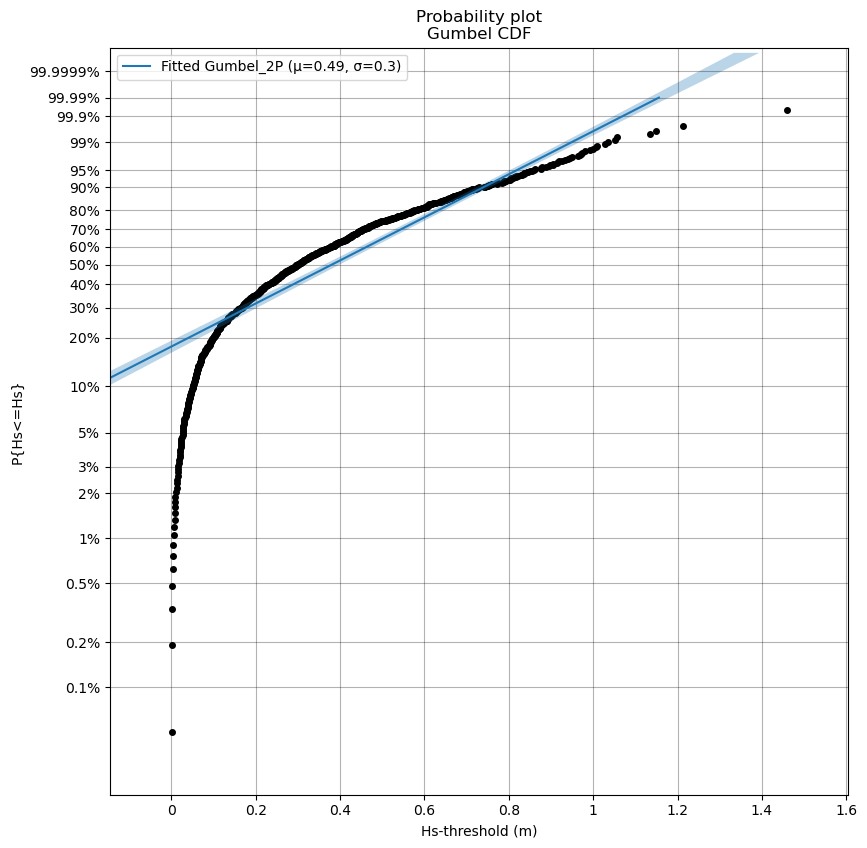

In [ ]:
wag = rf.Fit_Gumbel_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

Results from Fit_Exponential_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1408/0 (0% right censored) 

Parameter  Point Estimate  Standard Error    Lower CI    Upper CI
   Lambda         2.86252       0.0762865     2.71684     3.01602
 1/Lambda        0.349342         0.00931    0.331563    0.368074
    Gamma     0.000290625               0 0.000290625 0.000290625 

Goodness of fit    Value
 Log-likelihood  72.7986
           AICc -141.589
            BIC -131.097
             AD  19.9581 



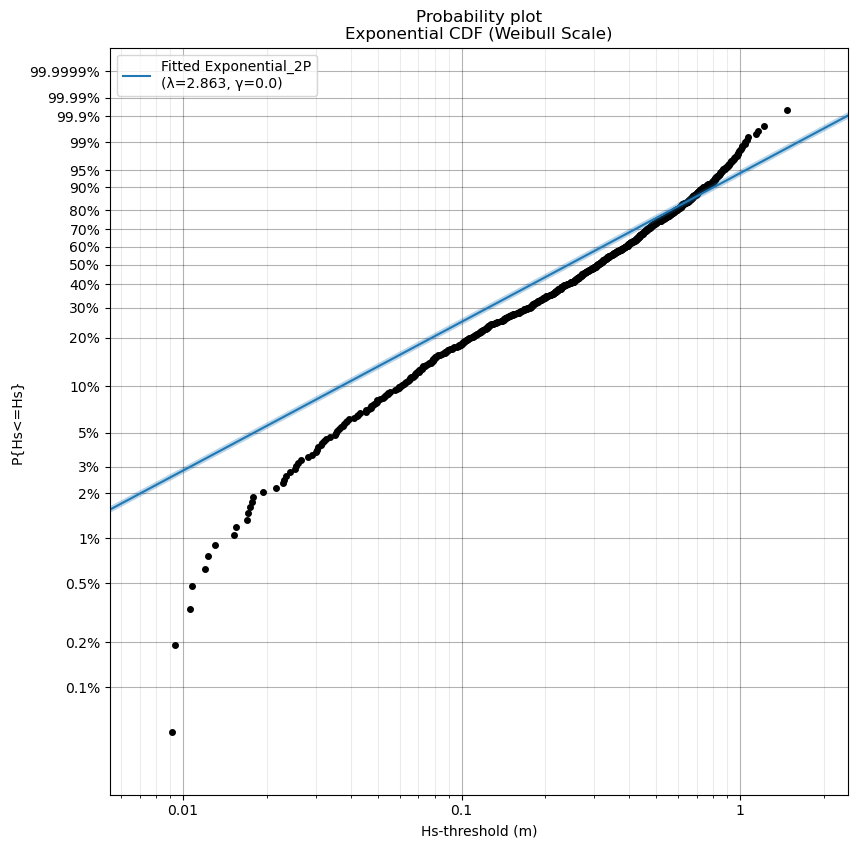

In [ ]:
wae = rf.Fit_Exponential_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

In [ ]:
#
#  Determine return period values
#
#
# define exceedance value for 100 yr return
# 
treturn = 200
numberyears = 30
numb = len(pot_maxima) / numberyears
prob = 1 - 1/(numb * treturn)
print(prob)

0.9998934659090909


In [ ]:
# Weibull 2
X_lower,X_point,X_upper = waw2.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull2P ',treturn,'Year return value is ',X_point,' (m)')

# Weibull 3
X_lower,X_point,X_upper = waw3.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull3P ',treturn,'Year return value is ',X_point,' (m)')

# Gumbel
X_lower,X_point,X_upper = wag.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Gumbel ',treturn,'Year return value is ',X_point,' (m)')

# Exponential
X_lower,X_point,X_upper = wae.distribution.CDF(CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Exponential ',treturn,'Year return value is ',X_point,' (m)')

Weibull2P  200 Year return value is  3.117616380950436  (m)
Weibull3P  200 Year return value is  3.117616380950436  (m)
Gumbel  200 Year return value is  2.0537878012148885  (m)
Exponential  200 Year return value is  4.09573893301181  (m)


c:\Users\jholl\tudelft-conda\envs\mude-base\Lib\site-packages\reliability\Fitters.py:440: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(


Results from Fit_Everything:
Analysis method: MLE
Failures / Right censored: 1408/0 (0% right censored) 

   Distribution    Alpha    Beta       Gamma  Alpha 1  Beta 1  Alpha 2  Beta 2 Proportion 1 DS       Mu    Sigma  Lambda  Log-likelihood     AICc      BIC       AD optimizer
     Weibull_CR                              0.439735 1.04103 0.851573 3.28852                                                   147.836 -287.643 -266.671 0.322557       TNC
Weibull_Mixture                              0.194187 1.09612  0.56384 2.15555     0.480037                                      147.308 -284.573 -258.366 0.342313       TNC
     Weibull_2P 0.373285 1.24221                                                                                                 117.117 -230.225 -219.734   4.8294       TNC
     Weibull_DS 0.373285 1.24221                                                             1                                   117.117 -228.216 -212.484   4.8294       TNC
     Weibull_3P 0.373285

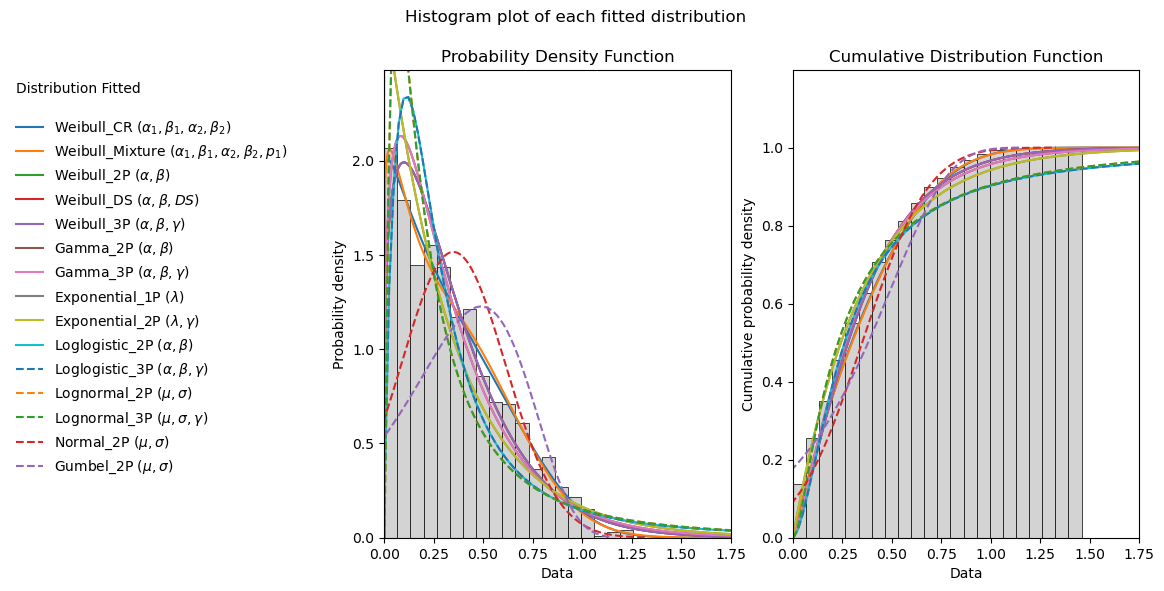

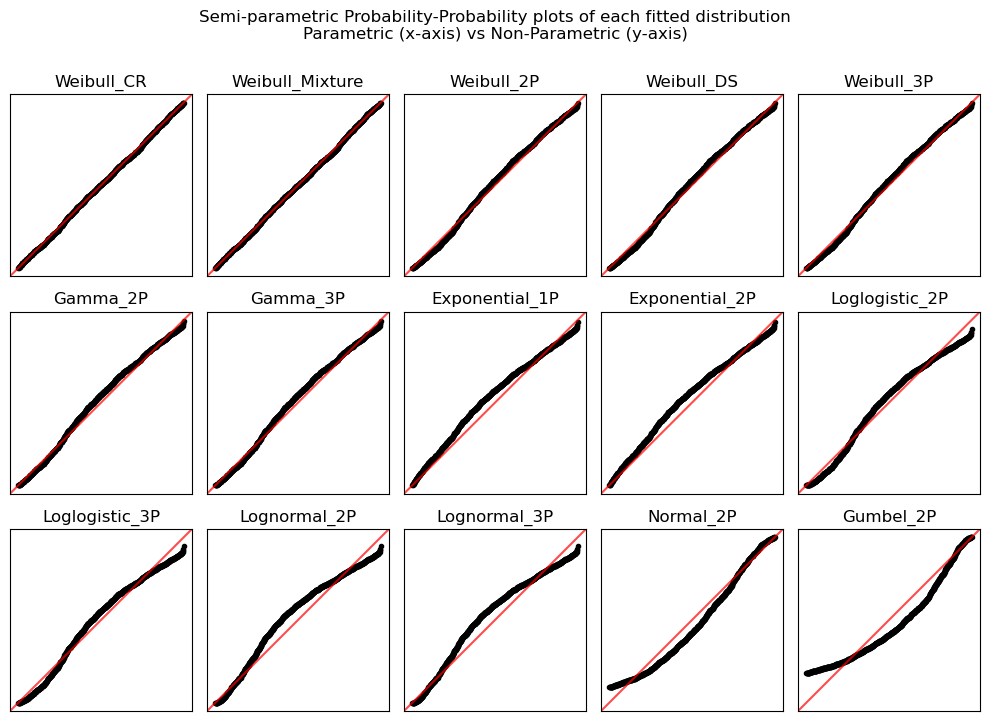

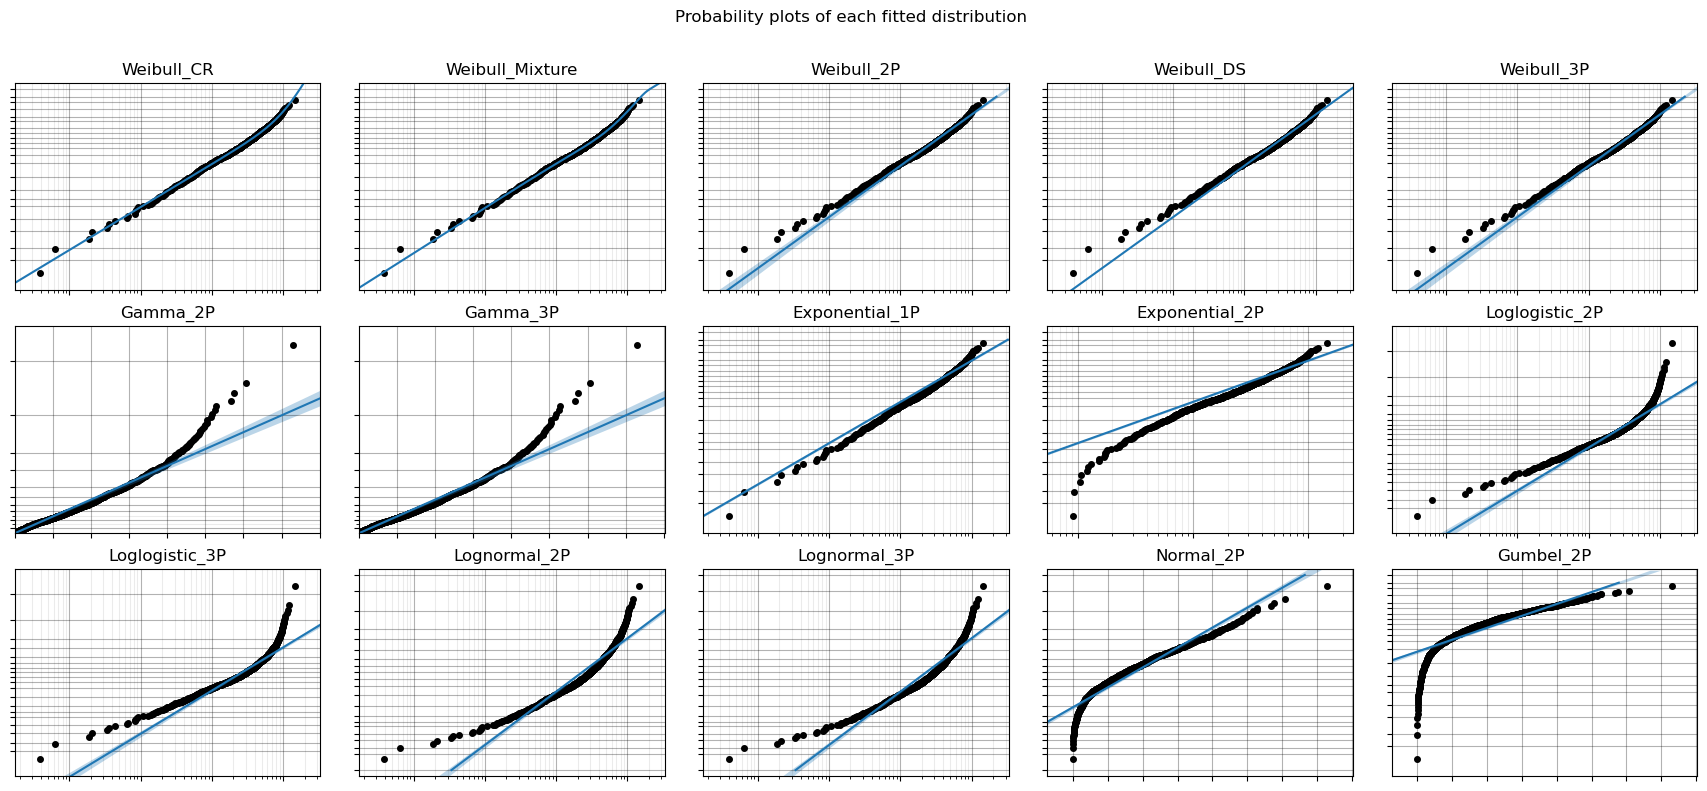

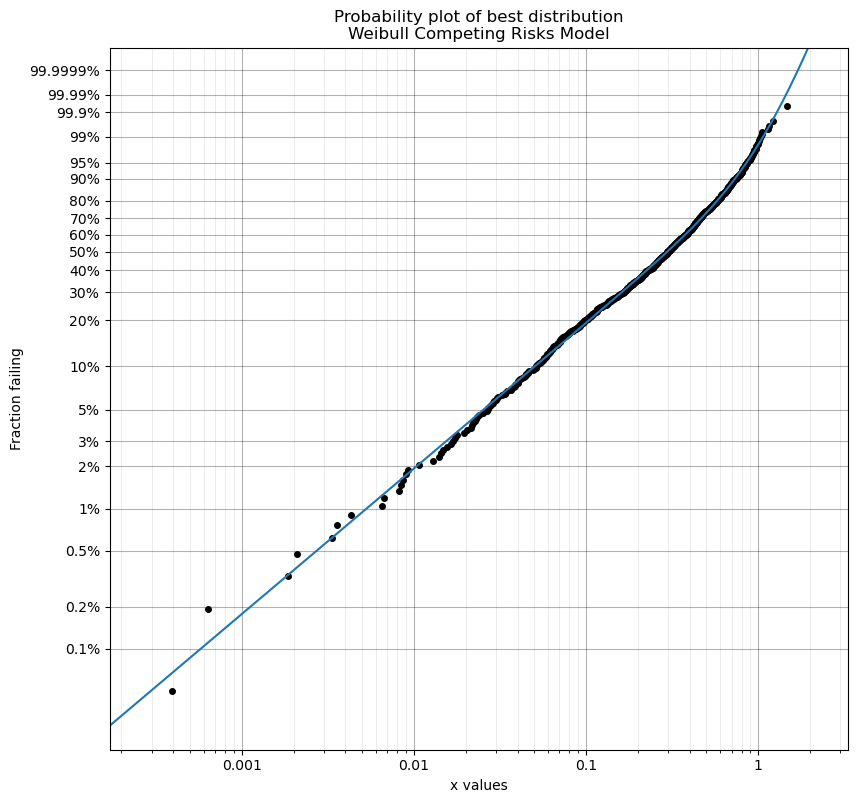

The best fitting distribution was: Weibull_CR


,Distribution,Alpha,Beta,Gamma,...,AICc,BIC,AD,optimizer
0,Weibull_CR,,,,...,-287.643,-266.671,0.322557,TNC
0,Weibull_Mixture,,,,...,-284.573,-258.366,0.342313,TNC
0,Weibull_2P,0.373285,1.24221,,...,-230.225,-219.734,4.8294,TNC
0,Weibull_DS,0.373285,1.24221,,...,-228.216,-212.484,4.8294,TNC
0,Weibull_3P,0.373285,1.24221,0,...,-228.216,-212.484,4.8294,TNC
0,Gamma_2P,0.266008,1.31437,,...,-199.436,-188.945,7.08964,TNC
0,Gamma_3P,0.266008,1.31437,0,...,-197.428,-181.695,7.08964,TNC
0,Exponential_1P,,,,...,-141.253,-136.006,20.131,TNC
0,Exponential_2P,,,0.000290625,...,-141.589,-131.097,19.9581,TNC
0,Loglogistic_2P,0.260864,1.65325,,...,82.0937,92.585,21.3285,TNC


No direct .parameters attribute for this distribution type.
Best distribution object:


In [ ]:
# Fit all distributions and print best distribution safely

results = rf.Fit_Everything(failures=dfmax)

print("The best fitting distribution was:", results.best_distribution_name)

# Show the fitted distribution ranking table
display(results.results)

# Try to print parameters, but avoid crashing for competing risks models
best_dist = results.best_distribution

if hasattr(best_dist, "parameters"):
    print("Parameters:", best_dist.parameters)
else:
    print("No direct .parameters attribute for this distribution type.")
    print("Best distribution object:")
    print(best_dist)

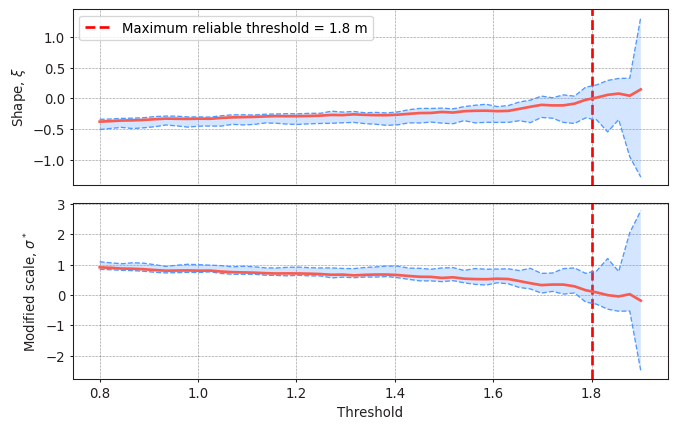

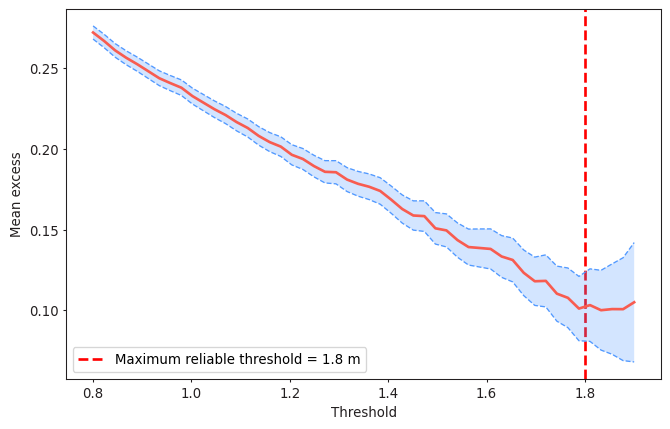

Number of POT peaks: 1408
Minimum time spacing [h]: 72.0
Number of peaks closer than 72 h: 0
GPD shape ξ: -0.29825291665178066
GPD scale σ: 0.44842520579394174
GPD location: 0
Upper bound Hs: 2.4035065233494155
Record length [years]: 30.00130050582832
POT peaks per year λ: 46.93129885241039


,Return period [years],Hs_wind POT-GPD [m]
0,1,1.926
1,10,2.163
2,50,2.255
3,100,2.283
4,200,2.305
5,490,2.328
6,500,2.329
7,1000,2.343
8,10000,2.373


In [ ]:
# ============================================================
# THRESHOLD CHECK + DESIGN VALUES - WIND WAVES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pyextremes import plot_parameter_stability, plot_mean_residual_life

# Make sure time is datetime
wave_data["time"] = pd.to_datetime(wave_data["time"])

# ============================================================
# THRESHOLD CHECK - WS2 / pyExtremes method
# ============================================================

data = (
    wave_data[["time", "Hs_wind"]]
    .dropna()
    .assign(time=lambda df: pd.to_datetime(df["time"]))
    .set_index("time")["Hs_wind"]
    .sort_index()
)

data.name = "Hs"

r = "72H"

# Threshold used for POT extraction in this notebook
threshold = 0.9

# Maximum reliable threshold shown in the plot
maximum_threshold = 1.8

# Realistic threshold range in metres for wind waves
thresholds = np.linspace(0.8, 1.9, 50)

# Parameter stability plot
plot_parameter_stability(
    data,
    thresholds=thresholds,
    r=r,
    alpha=0.95
)

for ax in plt.gcf().axes:
    ax.axvline(
        maximum_threshold,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Maximum reliable threshold = {maximum_threshold:.1f} m"
    )

for ax in plt.gcf().axes:
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend()
        break

plt.show()

# Mean residual life plot
plot_mean_residual_life(
    data,
    thresholds=thresholds
)

for ax in plt.gcf().axes:
    ax.axvline(
        maximum_threshold,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Maximum reliable threshold = {maximum_threshold:.1f} m"
    )
    ax.legend()

plt.show()


# ============================================================
# READ POT PEAKS
# ============================================================

pot_df = pd.read_csv("EVA result POT wind waves.csv")
pot_df["pot_time"] = pd.to_datetime(pot_df["pot_time"])

pot_maxima = pot_df["pot_maxima"].astype(float)
excess = pot_maxima - threshold

pot_df["dt_hours"] = pot_df["pot_time"].diff().dt.total_seconds() / 3600

print("Number of POT peaks:", len(pot_df))
print("Minimum time spacing [h]:", pot_df["dt_hours"].min())
print("Number of peaks closer than 72 h:", (pot_df["dt_hours"] < 72).sum())


# ============================================================
# FIT GPD TO POT EXCESSES
# ============================================================

gpd_shape, gpd_loc, gpd_scale = stats.genpareto.fit(excess, floc=0)

print("GPD shape ξ:", gpd_shape)
print("GPD scale σ:", gpd_scale)
print("GPD location:", gpd_loc)

if gpd_shape < 0:
    upper_bound = threshold - gpd_scale / gpd_shape
    print("Upper bound Hs:", upper_bound)


# ============================================================
# RETURN VALUES
# ============================================================

record_years = (
    wave_data["time"].max() - wave_data["time"].min()
).total_seconds() / (365.2425 * 24 * 3600)

lambda_pot = len(pot_maxima) / record_years

print("Record length [years]:", record_years)
print("POT peaks per year λ:", lambda_pot)

def pot_gpd_return_value(R):
    p_non_exceed_excess = 1 - 1 / (lambda_pot * R)
    return threshold + stats.genpareto.ppf(
        p_non_exceed_excess,
        c=gpd_shape,
        loc=0,
        scale=gpd_scale
    )

return_periods = [1, 10, 50, 100, 200, 490, 500, 1000, 10000]

design_table_wind = pd.DataFrame({
    "Return period [years]": return_periods,
    "Hs_wind POT-GPD [m]": [pot_gpd_return_value(R) for R in return_periods]
})

design_table_wind["Hs_wind POT-GPD [m]"] = design_table_wind["Hs_wind POT-GPD [m]"].round(3)

display(design_table_wind)

In [ ]:
# ============================================================
# SCATTERPLOT: PERIOD VS WAVE HEIGHT
# Full dataset + detected POT peaks
# ============================================================

import plotly.graph_objects as go

# Use the correct period column
period_series = wave_data["Peak_period"]

fig = go.Figure()

# All wave data points
fig.add_trace(go.Scatter(
    x=period_series,
    y=time_series,
    mode="markers",
    marker=dict(
        size=4,
        opacity=0.35,
        color="blue"
    ),
    name="All wave data"
))

# POT peaks with corresponding period at the same index/timestamp
fig.add_trace(go.Scatter(
    x=period_series.iloc[indices],
    y=pot_maxima.values,
    mode="markers",
    marker=dict(
        size=8,
        color="red",
        symbol="cross"
    ),
    name="Detected POT peaks"
))

fig.update_layout(
    title="Wave height vs peak wave period",
    xaxis_title="Peak wave period Tp [s]",
    yaxis_title="Significant wave height Hs [m]",
    template="plotly_white"
)

fig.show()